Download dataset

In [1]:
#
# clean main folders
!rm -r *
!ls

# Creating a dataset directory.
# -p Will also create any intermediate directories that don't exist
!mkdir -p ./datasets/us-baby-name/zip
!mkdir -p ./datasets/us-baby-name/data

# download the dataset from SSA and unzip it
!wget 'https://www.ssa.gov/oact/babynames/state/namesbystate.zip' -O "./datasets/us-baby-name/zip/namesbystate.zip"
!unzip {"./datasets/us-baby-name/zip/namesbystate.zip"} -d {"./datasets/us-baby-name/data"}

--2026-06-27 15:48:45--  https://www.ssa.gov/oact/babynames/state/namesbystate.zip
Resolving www.ssa.gov (www.ssa.gov)... 173.223.234.197, 173.223.234.208, 2600:1406:5400::170f:f139, ...
Connecting to www.ssa.gov (www.ssa.gov)|173.223.234.197|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24383479 (23M) [application/zip]
Saving to: ‘./datasets/us-baby-name/zip/namesbystate.zip’

./datasets/us-baby- 100%[===================>]  23.25M  65.2MB/s    in 0.4s    

2026-06-27 15:48:45 (65.2 MB/s) - ‘./datasets/us-baby-name/zip/namesbystate.zip’ saved [24383479/24383479]

Archive:  ./datasets/us-baby-name/zip/namesbystate.zip
  inflating: ./datasets/us-baby-name/data/AK.TXT  
  inflating: ./datasets/us-baby-name/data/AL.TXT  
  inflating: ./datasets/us-baby-name/data/AR.TXT  
  inflating: ./datasets/us-baby-name/data/AZ.TXT  
  inflating: ./datasets/us-baby-name/data/CA.TXT  
  inflating: ./datasets/us-baby-name/data/CO.TXT  
  inflating: ./datasets/us-baby-name/data

In [2]:
# Test the downloaded data
!ls 'datasets/us-baby-name/data'

AK.TXT	CT.TXT	IA.TXT	LA.TXT	MO.TXT	NH.TXT	OK.TXT	StateReadMe.pdf  WA.TXT
AL.TXT	DC.TXT	ID.TXT	MA.TXT	MS.TXT	NJ.TXT	OR.TXT	TN.TXT		 WI.TXT
AR.TXT	DE.TXT	IL.TXT	MD.TXT	MT.TXT	NM.TXT	PA.TXT	TX.TXT		 WV.TXT
AZ.TXT	FL.TXT	IN.TXT	ME.TXT	NC.TXT	NV.TXT	RI.TXT	UT.TXT		 WY.TXT
CA.TXT	GA.TXT	KS.TXT	MI.TXT	ND.TXT	NY.TXT	SC.TXT	VA.TXT
CO.TXT	HI.TXT	KY.TXT	MN.TXT	NE.TXT	OH.TXT	SD.TXT	VT.TXT


Create dataframe

In [3]:
import glob
import pandas as pd

path = 'datasets/us-baby-name/data'
file_list = glob.glob(f'{path}/*.TXT')
all_name_df = None
for file_path in file_list:
  df_file = pd.read_csv(file_path, sep=",", header=None)
  df_file.columns = ['State', 'Gender',  'Year', 'Name', 'Number']
  if all_name_df is None:
    all_name_df = df_file
  else:
    all_name_df = pd.concat([all_name_df, df_file])
all_name_df = all_name_df[['State', 'Gender', 'Name', 'Number', 'Year']]  # rearrange the columns
print(all_name_df.head(5))

  State Gender      Name  Number  Year
0    IL      F      Mary    1076  1910
1    IL      F     Helen     917  1910
2    IL      F   Dorothy     553  1910
3    IL      F  Margaret     501  1910
4    IL      F   Mildred     426  1910


In [4]:
# Check all_name_df's dimension (x, y)
all_name_df.shape

(6696687, 5)

Create SQL DB using the dataframe

In [5]:
!mkdir -p ./datasets/us-baby-name/sql

import sqlite3
DB_PATH_BABY = 'datasets/us-baby-name/sql/database.sqlite'
!rm -f ./datasets/us-baby-name/sql/database.sqlite

to_db = list(all_name_df.itertuples(index=False))
con = sqlite3.connect(DB_PATH_BABY)
cur = con.cursor()
# creates a table named (Names) with the dataset data and the following columns:
# 'State', 'Gender', 'Name', 'Number', and 'Year' (5pt)
cur.execute("CREATE TABLE babyName (State, Gender, Name, Number, Year);")

#  Load the data using a Batch INSERT SQL Query (2pt):
cur.executemany("INSERT INTO babyName (State, Gender, Name, Number, Year) VALUES (?, ?, ?, ?, ?);", to_db)
con.commit()
con.close()

In [6]:
# Test the database

!ls datasets/us-baby-name/sql/
conn = sqlite3.connect(DB_PATH_BABY) # connecting to the database
c = conn.cursor() # creating a cursor object
print("The number of names in the dataset: %s" % c.execute("SELECT count(*) FROM babyName" ).fetchone()) # execute a query & fetch the results
c.close() # close the cursor

database.sqlite
The number of names in the dataset: 6696687


In [7]:
import timeit
import sqlite3

!ls datasets/us-baby-name/sql/

# Connect to DB
conn = sqlite3.connect(DB_PATH_BABY)
# Create a cursor object
c = conn.cursor()
# Write a query that returns the statistics for the name William (5pt)
# Use the the timeit package to measure the time it takes the query to run (5pt).
query_for_stat = "SELECT Gender, sum(Number) FROM babyName WHERE Name == 'William' GROUP BY Gender"
print(f"The number of Female (F) and Male (M) named Williams in the dataset: {c.execute(query_for_stat).fetchall()}")
conn.commit()
conn.close() # close the cursor

# Use the the timeit package to measure the time it takes the query to run (5pt).
num_of_runs = 100
without_time = timeit.timeit(f'c.execute("{query_for_stat}").fetchone();', setup='import sqlite3; conn = sqlite3.connect(\'datasets/us-baby-name/sql/database.sqlite\'); c = conn.cursor();', number=num_of_runs)
print(f'Time to run query without indices (average of {num_of_runs} runs): {without_time/num_of_runs:.5f}')

# Create an index on the Name column and use the the timeit package to measure the time it takes the query to run with the index (5pt)
conn = sqlite3.connect(DB_PATH_BABY) # connecting to the database
c = conn.cursor() # creating a cursor object
# c.execute("DROP INDEX name_idx;")
c.execute("CREATE INDEX name_idx ON babyName (Name)")
conn.commit()
conn.close() # close the cursor

with_time = timeit.timeit(f'c.execute("{query_for_stat}").fetchone();', setup='import sqlite3; conn = sqlite3.connect(\'datasets/us-baby-name/sql/database.sqlite\'); c = conn.cursor();', number=num_of_runs)
print(f'Time to run query with indices (average of {num_of_runs} runs): {with_time/num_of_runs:.5f}')

database.sqlite
The number of Female (F) and Male (M) named Williams in the dataset: [('F', 10212), ('M', 3973251)]
Time to run query without indices (average of 100 runs): 0.51294
Time to run query with indices (average of 100 runs): 0.01869


Create a NoSQL database on TinyDB using the dataframeb

In [8]:
!pip install tinydb
from tinydb import TinyDB

In [9]:
# Naive mode: hanya contoh kecil agar notebook tidak crash
# Jangan print semua records karena datanya besar
sample_records = all_name_df.head(100).to_dict(orient='records')
print(f"Jumlah sample records: {len(sample_records)}")

try:
    db = TinyDB('dataframe_db_sample.json')
    db.truncate()
    db.insert_multiple(sample_records)

    print("Data sample berhasil dimasukkan ke TinyDB.")
    print("Contoh 5 data:")
    for item in db.all()[:5]:
        print(item)
finally:
    db.close()

Jumlah sample records: 100
Data sample berhasil dimasukkan ke TinyDB.
Contoh 5 data:
{'State': 'IL', 'Gender': 'F', 'Name': 'Mary', 'Number': 1076, 'Year': 1910}
{'State': 'IL', 'Gender': 'F', 'Name': 'Helen', 'Number': 917, 'Year': 1910}
{'State': 'IL', 'Gender': 'F', 'Name': 'Dorothy', 'Number': 553, 'Year': 1910}
{'State': 'IL', 'Gender': 'F', 'Name': 'Margaret', 'Number': 501, 'Year': 1910}
{'State': 'IL', 'Gender': 'F', 'Name': 'Mildred', 'Number': 426, 'Year': 1910}


Big data approach: chunking or paginating

In [10]:
from time import time

# Big data approach: chunking / pagination
# Dibuat ringan agar aman untuk RAM terbatas
page_size = 10_000
total_rows = min(50_000, len(all_name_df))
num_pages = (total_rows + page_size - 1) // page_size

begin = time()

try:
    db = TinyDB('dataframe_db.json')
    db.truncate()

    for i in range(0, total_rows, page_size):
        page_df = all_name_df.iloc[i:i + page_size]
        df_records = page_df.to_dict(orient='records')
        db.insert_multiple(df_records)
        print(f"Processing Page {i//page_size + 1} / {num_pages}")

    end = time()
    inserted_rows = len(db)
    print("Number of records in the database:", inserted_rows)
    print("Contoh 5 data:")
    for item in db.all()[:5]:
        print(item)
finally:
    db.close()

total_time = end - begin
print(f"Total time: {total_time:.4f} s")
print(f"Time/record: {total_time / total_rows:.10f} s")

Processing Page 1 / 5
Processing Page 2 / 5
Processing Page 3 / 5
Processing Page 4 / 5
Processing Page 5 / 5
Number of records in the database: 50000
Contoh 5 data:
{'State': 'IL', 'Gender': 'F', 'Name': 'Mary', 'Number': 1076, 'Year': 1910}
{'State': 'IL', 'Gender': 'F', 'Name': 'Helen', 'Number': 917, 'Year': 1910}
{'State': 'IL', 'Gender': 'F', 'Name': 'Dorothy', 'Number': 553, 'Year': 1910}
{'State': 'IL', 'Gender': 'F', 'Name': 'Margaret', 'Number': 501, 'Year': 1910}
{'State': 'IL', 'Gender': 'F', 'Name': 'Mildred', 'Number': 426, 'Year': 1910}
Total time: 0.5762 s
Time/record: 0.0000115249 s


In [11]:
# Assignment
# Cari nilai page_size terbaik untuk mendapatkan waktu insertion terpendek untuk RAM yang tersedia
# dengan membuat grafik plot waktu (y-axis) terhadap page_size (x-axis)
# Ambil rata-rata waktu insertion per row, bandingkan dengan waktu insertion di SQL
# Jelaskan hasil temuanmu.

### Revisi Assignment: Benchmark `page_size` TinyDB vs SQLite
Kode dibuat ringan agar tidak terlalu lama dijalankan di RAM terbatas. Data yang diuji memakai sample dari `all_name_df`, lalu beberapa `page_size` dibandingkan berdasarkan waktu insertion.

In [12]:
import os, time, gc, sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from tinydb import TinyDB

# Sample data agar benchmark tidak terlalu lama
# Naikkan ke 100_000 kalau laptop/Colab masih kuat
total_rows = min(50_000, len(all_name_df))
test_df = all_name_df.iloc[:total_rows].copy()

# Konversi sekali saja supaya loop benchmark lebih cepat
records_all = test_df.to_dict(orient="records")
sql_rows = list(test_df.itertuples(index=False, name=None))

# Kandidat page_size sesuai RAM yang tersedia
page_sizes = [1_000, 5_000, 10_000, 25_000, 50_000]
page_sizes = [p for p in page_sizes if p <= total_rows]

print("Total data uji:", total_rows)
print("Page size diuji:", page_sizes)

Total data uji: 50000
Page size diuji: [1000, 5000, 10000, 25000, 50000]


In [13]:
def benchmark_tinydb(records, page_size, db_path="tinydb_benchmark.json"):
    if os.path.exists(db_path):
        os.remove(db_path)

    start_time = time.perf_counter()
    db = TinyDB(db_path)
    db.truncate()

    for start in range(0, len(records), page_size):
        page_records = records[start:start + page_size]
        db.insert_multiple(page_records)

    db.close()
    return time.perf_counter() - start_time

In [14]:
results = []

for ps in page_sizes:
    print(f"Testing page_size = {ps}")

    total_time = benchmark_tinydb(records_all, ps)
    avg_time = total_time / total_rows

    results.append({
        "database": "TinyDB",
        "page_size": ps,
        "total_time_sec": total_time,
        "avg_time_per_row_sec": avg_time
    })

    gc.collect()

result_df = pd.DataFrame(results)
result_df

Testing page_size = 1000
Testing page_size = 5000
Testing page_size = 10000
Testing page_size = 25000
Testing page_size = 50000


,database,page_size,total_time_sec,avg_time_per_row_sec
0,TinyDB,1000,7.988878,0.000160
1,TinyDB,5000,0.776204,0.000016
2,TinyDB,10000,0.433724,0.000009
3,TinyDB,25000,0.202467,0.000004
4,TinyDB,50000,0.130258,0.000003


In [15]:
best_row = result_df.loc[result_df["total_time_sec"].idxmin()]

best_page_size = int(best_row["page_size"])
best_time = best_row["total_time_sec"]
best_avg = best_row["avg_time_per_row_sec"]

print("Page_size terbaik:", best_page_size)
print(f"Total waktu TinyDB: {best_time:.4f} detik")
print(f"Rata-rata waktu per row: {best_avg:.10f} detik/row")

Page_size terbaik: 50000
Total waktu TinyDB: 0.1303 detik
Rata-rata waktu per row: 0.0000026052 detik/row


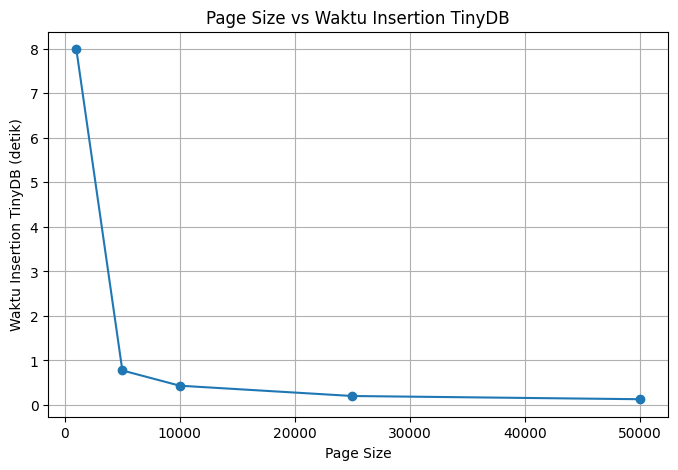

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(result_df["page_size"], result_df["total_time_sec"], marker="o")

plt.xlabel("Page Size")
plt.ylabel("Waktu Insertion TinyDB (detik)")
plt.title("Page Size vs Waktu Insertion TinyDB")
plt.grid(True)
plt.show()

In [17]:
def benchmark_sqlite(rows, db_path="sqlite_benchmark.sqlite", page_size=10_000):
    if os.path.exists(db_path):
        os.remove(db_path)

    start_time = time.perf_counter()
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()

    cur.execute("""
        CREATE TABLE babyName (
            State TEXT,
            Gender TEXT,
            Name TEXT,
            Number INTEGER,
            Year INTEGER
        )
    """)

    for start in range(0, len(rows), page_size):
        batch = rows[start:start + page_size]
        cur.executemany(
            "INSERT INTO babyName (State, Gender, Name, Number, Year) VALUES (?, ?, ?, ?, ?)",
            batch
        )

    conn.commit()
    conn.close()
    return time.perf_counter() - start_time

In [18]:
sql_time = benchmark_sqlite(sql_rows)
sql_avg = sql_time / total_rows

comparison_df = pd.DataFrame([
    {
        "database": "TinyDB",
        "page_size": best_page_size,
        "total_time_sec": best_time,
        "avg_time_per_row_sec": best_avg
    },
    {
        "database": "SQLite",
        "page_size": "batch 10_000",
        "total_time_sec": sql_time,
        "avg_time_per_row_sec": sql_avg
    }
])

comparison_df

,database,page_size,total_time_sec,avg_time_per_row_sec
0,TinyDB,50000,0.130258,0.000003
1,SQLite,batch 10_000,0.113344,0.000002


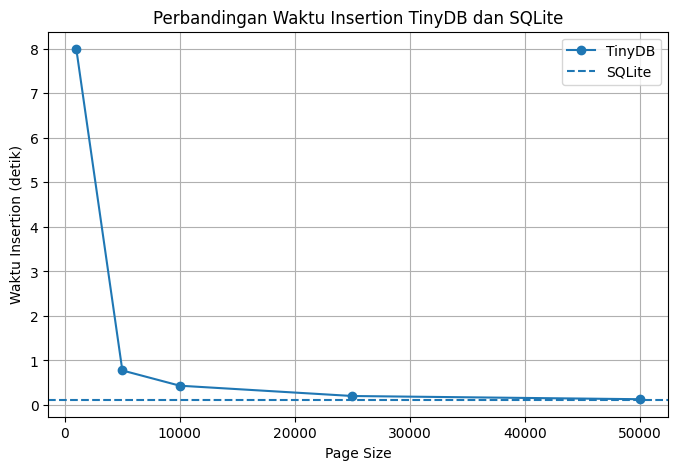

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(result_df["page_size"], result_df["total_time_sec"], marker="o", label="TinyDB")
plt.axhline(y=sql_time, linestyle="--", label="SQLite")

plt.xlabel("Page Size")
plt.ylabel("Waktu Insertion (detik)")
plt.title("Perbandingan Waktu Insertion TinyDB dan SQLite")
plt.legend()
plt.grid(True)
plt.show()

## Penjelasan Hasil Assignment

Eksperimen ini dilakukan untuk mencari nilai `page_size` terbaik pada proses insertion data ke TinyDB.  
`page_size` digunakan sebagai ukuran batch/chunk data yang dimasukkan ke database dalam satu kali proses.

Konsep ini sesuai dengan materi **Chunking Big Data**, karena data besar tidak selalu aman dimasukkan sekaligus ke memori. Dengan chunking, data diproses secara bertahap agar penggunaan CPU, RAM, dan I/O lebih terkendali.

Pada percobaan ini digunakan **50.000 row** dari dataset `all_name_df`. Jumlah ini dipilih agar benchmark tetap stabil dan tidak membuat proses TinyDB terlalu lama pada RAM yang tersedia.


In [ ]:
# Tabel ringkasan hasil benchmark TinyDB
summary_result_df = result_df.copy()
summary_result_df["total_time_sec"] = summary_result_df["total_time_sec"].round(6)
summary_result_df["avg_time_per_row_sec"] = summary_result_df["avg_time_per_row_sec"].round(10)

summary_result_df


## Grafik Page Size terhadap Waktu Insertion TinyDB

Grafik berikut menunjukkan hubungan antara `page_size` dan waktu insertion TinyDB.  
Semakin besar `page_size`, jumlah batch yang diproses menjadi lebih sedikit, sehingga waktu insertion cenderung lebih cepat.

Namun, `page_size` yang terlalu besar tetap perlu diperhatikan karena dapat meningkatkan penggunaan RAM.


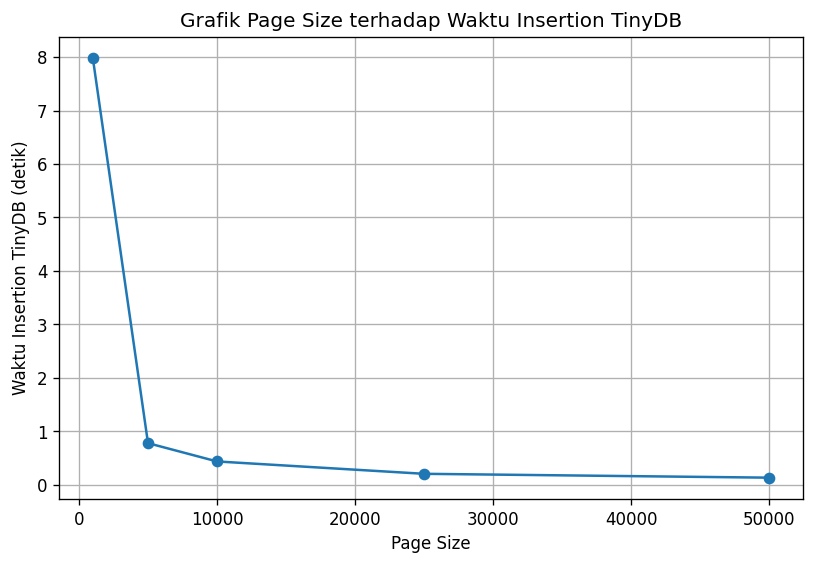

In [ ]:
# Grafik hasil benchmark page_size vs waktu insertion TinyDB
plt.figure(figsize=(8, 5))
plt.plot(result_df["page_size"], result_df["total_time_sec"], marker="o")

plt.xlabel("Page Size")
plt.ylabel("Waktu Insertion TinyDB (detik)")
plt.title("Grafik Page Size terhadap Waktu Insertion TinyDB")
plt.grid(True)
plt.show()


## Perbandingan TinyDB dengan SQLite

Berdasarkan hasil benchmark, `page_size` terbaik untuk TinyDB adalah **50000**.  
Nilai tersebut menghasilkan waktu insertion TinyDB paling pendek, yaitu sekitar **0.1303 detik**.

Rata-rata waktu insertion TinyDB per row adalah sekitar **0.0000026052 detik/row**.  
Sementara itu, waktu insertion SQLite adalah sekitar **0.1133 detik**, dengan rata-rata **0.0000022669 detik/row**.

Hasil ini menunjukkan bahwa SQLite sedikit lebih cepat dibandingkan TinyDB untuk data terstruktur, karena SQLite menggunakan engine database relasional dan mendukung batch insert secara lebih efisien. TinyDB lebih sederhana karena berbasis file JSON, tetapi performanya dapat menurun ketika data semakin besar.


In [ ]:
# Tabel perbandingan TinyDB terbaik dengan SQLite
comparison_df["total_time_sec"] = comparison_df["total_time_sec"].round(6)
comparison_df["avg_time_per_row_sec"] = comparison_df["avg_time_per_row_sec"].round(10)

comparison_df


## Grafik Perbandingan TinyDB dan SQLite

Grafik berikut membandingkan waktu insertion terbaik TinyDB dengan waktu insertion SQLite.  
SQLite terlihat sedikit lebih cepat, tetapi TinyDB tetap dapat digunakan sebagai contoh NoSQL sederhana untuk memahami konsep insertion berbasis dokumen/file JSON.


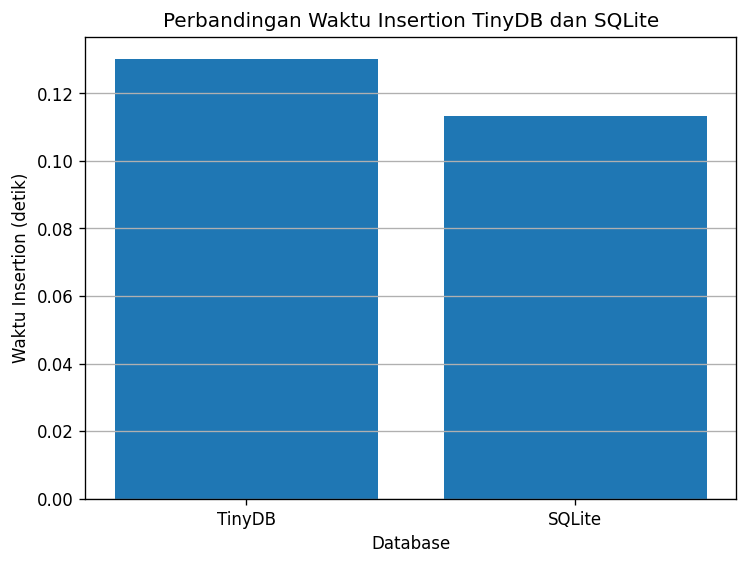

In [ ]:
# Grafik perbandingan waktu insertion TinyDB terbaik vs SQLite
plt.figure(figsize=(7, 5))
plt.bar(comparison_df["database"], comparison_df["total_time_sec"])

plt.xlabel("Database")
plt.ylabel("Waktu Insertion (detik)")
plt.title("Perbandingan Waktu Insertion TinyDB dan SQLite")
plt.grid(axis="y")
plt.show()


## Kesimpulan

Dari hasil pengujian, `page_size` terbaik untuk TinyDB pada RAM yang tersedia adalah **50000**.  
Nilai tersebut memberikan waktu insertion paling pendek dibandingkan kandidat `page_size` lain.

Hasil benchmark juga menunjukkan bahwa pemilihan `page_size` berpengaruh besar terhadap performa insertion. Jika `page_size` terlalu kecil, proses menjadi lambat karena jumlah batch terlalu banyak. Jika terlalu besar, penggunaan RAM dapat meningkat.

Secara umum, SQLite lebih cepat dan stabil untuk data tabular/terstruktur. TinyDB lebih cocok untuk implementasi NoSQL sederhana, tetapi kurang optimal untuk dataset besar karena penyimpanan berbasis JSON memiliki beban serialisasi file yang lebih tinggi.

Dengan demikian, hasil percobaan sudah sesuai dengan konsep **SQL vs NoSQL**, **Big Data chunking**, dan **pengujian performa insertion** pada materi.
